<a href="https://colab.research.google.com/github/NCI2433-Dev/beijing-house-price-prediction/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor, plot_importance

%matplotlib inline

In [4]:
# Upload and load the dataset

uploaded = files.upload()

df = pd.read_csv("beijing_housing_cleaned.csv")

print(df.shape)
df.head()

Saving beijing_housing_cleaned.csv to beijing_housing_cleaned (1).csv
(318819, 24)


,Lng,Lat,followers,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,buildingType,...,elevator,fiveYearsProperty,subway,district,communityAverage,tradeYear,tradeMonth,tradeQuarter,houseAge,floorNumber
0,116.475489,40.019520,106,415.0,131.00,2,1,1,1,1.0,...,1.0,0.0,1.0,7,56021.0,2016,8,3,11.0,26.0
1,116.453917,39.881534,126,575.0,132.38,2,2,1,2,1.0,...,1.0,1.0,0.0,7,71539.0,2016,7,3,12.0,22.0
2,116.561978,39.877145,48,1030.0,198.00,3,2,1,3,4.0,...,1.0,0.0,0.0,7,48160.0,2016,12,4,11.0,4.0
3,116.438010,40.076114,138,297.5,134.00,3,1,1,1,1.0,...,1.0,0.0,0.0,6,51238.0,2016,9,3,8.0,21.0
4,116.428392,39.886229,286,392.0,81.00,2,1,1,1,4.0,...,0.0,1.0,1.0,1,62588.0,2016,8,3,56.0,6.0


In [5]:
# Separate features and target variable

X = df.drop("totalPrice", axis=1)
y = df["totalPrice"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (318819, 23)
Target: (318819,)


In [6]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (255055, 23)
Testing: (63764, 23)


In [7]:
# Standardize the data for Linear Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(255055, 23)
(63764, 23)


In [8]:
# Train and evaluate the Linear Regression model

model = LinearRegression()

start = time.time()
model.fit(X_train_scaled, y_train)
training_time = time.time() - start

start = time.time()
y_pred = model.predict(X_test_scaled)
prediction_time = time.time() - start

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

lr_mae = mae
lr_rmse = rmse
lr_r2 = r2
lr_train_time = training_time
lr_prediction_time = prediction_time

print("="*50)
print("Linear Regression Results")
print("="*50)
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")
print(f"Training Time : {training_time:.4f} seconds")
print(f"Prediction Time: {prediction_time:.4f} seconds")

Linear Regression Results
MAE : 71.84
RMSE: 113.35
R²  : 0.7569
Training Time : 0.3534 seconds
Prediction Time: 0.0144 seconds


In [9]:
# Train and evaluate the Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_model.fit(X_train, y_train)
training_time = time.time() - start

start = time.time()
y_pred = rf_model.predict(X_test)
prediction_time = time.time() - start

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

rf_mae = mae
rf_rmse = rmse
rf_r2 = r2
rf_train_time = training_time
rf_prediction_time = prediction_time

print("="*50)
print("Random Forest Results")
print("="*50)
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")
print(f"Training Time : {training_time:.2f} seconds")
print(f"Prediction Time: {prediction_time:.4f} seconds")

Random Forest Results
MAE : 26.54
RMSE: 57.46
R²  : 0.9375
Training Time : 286.46 seconds
Prediction Time: 2.9049 seconds


                Feature  Importance
3                square    0.419194
17     communityAverage    0.311013
18            tradeYear    0.201534
19           tradeMonth    0.021163
1                   Lat    0.007015
0                   Lng    0.006176
22          floorNumber    0.004909
2             followers    0.004788
12          ladderRatio    0.003186
9      constructionTime    0.003161
21             houseAge    0.003154
20         tradeQuarter    0.002841
4            livingRoom    0.001822
16             district    0.001673
10  renovationCondition    0.001498
7              bathRoom    0.001442
5           drawingRoom    0.001065
8          buildingType    0.000924
14    fiveYearsProperty    0.000808
11    buildingStructure    0.000734
13             elevator    0.000734
15               subway    0.000629
6               kitchen    0.000538


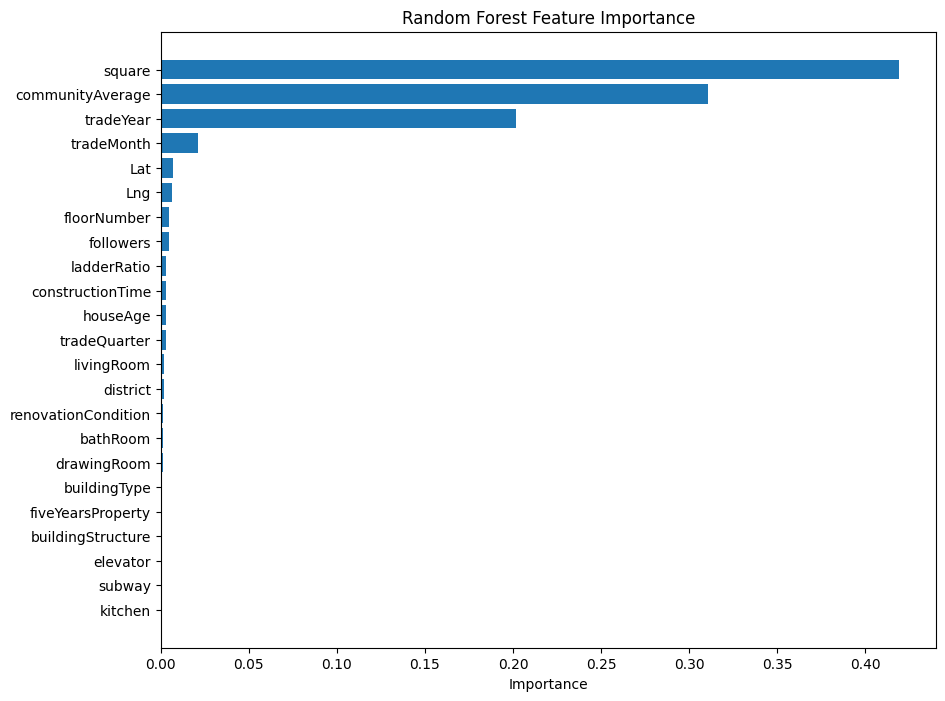

In [10]:
# Display Random Forest feature importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,8))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [11]:
# Train and evaluate the XGBoost model

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

start = time.time()
xgb.fit(X_train, y_train)
training_time = time.time() - start

start = time.time()
y_pred = xgb.predict(X_test)
prediction_time = time.time() - start

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

xgb_mae = mae
xgb_rmse = rmse
xgb_r2 = r2
xgb_train_time = training_time
xgb_prediction_time = prediction_time

print("="*50)
print("XGBoost Results")
print("="*50)
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")
print(f"Training Time : {training_time:.2f} seconds")
print(f"Prediction Time: {prediction_time:.4f} seconds")

XGBoost Results
MAE : 28.34
RMSE: 52.98
R²  : 0.9469
Training Time : 10.00 seconds
Prediction Time: 0.3692 seconds


                Feature  Importance
3                square    0.218249
18            tradeYear    0.183158
17     communityAverage    0.170963
7              bathRoom    0.080824
16             district    0.038363
4            livingRoom    0.035206
10  renovationCondition    0.033615
20         tradeQuarter    0.033351
11    buildingStructure    0.026579
13             elevator    0.025580
19           tradeMonth    0.024513
1                   Lat    0.024367
5           drawingRoom    0.019679
0                   Lng    0.016643
2             followers    0.013831
22          floorNumber    0.011285
12          ladderRatio    0.010198
15               subway    0.007550
9      constructionTime    0.007067
8          buildingType    0.005747
6               kitchen    0.005457
14    fiveYearsProperty    0.004195
21             houseAge    0.003578


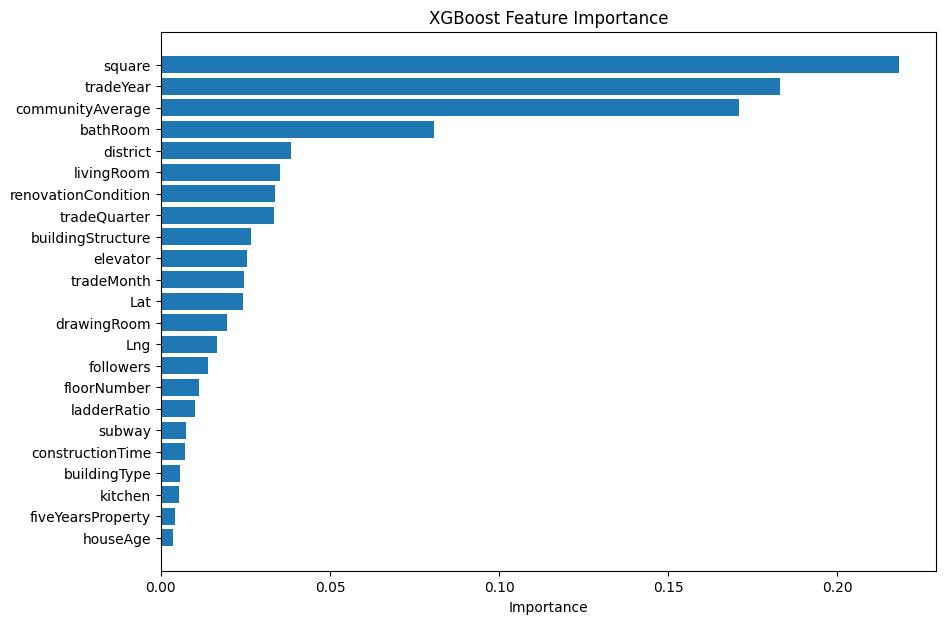

In [12]:
# Display XGBoost feature importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,7))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

In [13]:
# Compare the performance of all models

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R²": [
        lr_r2,
        rf_r2,
        xgb_r2
    ],
    "Training Time": [
        lr_train_time,
        rf_train_time,
        xgb_train_time
    ],
    "Prediction Time": [
        lr_prediction_time,
        rf_prediction_time,
        xgb_prediction_time
    ]
})

print(results)

               Model        MAE        RMSE        R²  Training Time  \
0  Linear Regression  71.841614  113.351683  0.756898       0.353444   
1      Random Forest  26.538057   57.463897  0.937523     286.455706   
2            XGBoost  28.339468   52.979292  0.946894      10.004734   

   Prediction Time  
0         0.014378  
1         2.904898  
2         0.369209  


             Actual     Predicted         Error  Absolute Error  \
count  63764.000000  63764.000000  63764.000000    63764.000000   
mean     348.861826    348.968170     -0.106311       28.339468   
std      229.899025    223.554199     52.979601       44.762835   
min        0.100000      3.169234  -2768.353516        0.002716   
25%      204.000000    207.960171    -17.429859        7.727947   
50%      295.000000    295.166092     -0.028488       17.442540   
75%      427.000000    425.859215     17.445480       34.381542   
max    11600.000000  12305.530273   2982.589111     2982.589111   

       Percentage Error  
count      63764.000000  
mean         156.434819  
std         5831.138170  
min            0.000551  
25%            2.833553  
50%            6.112637  
75%           10.834733  
max       536185.339355  


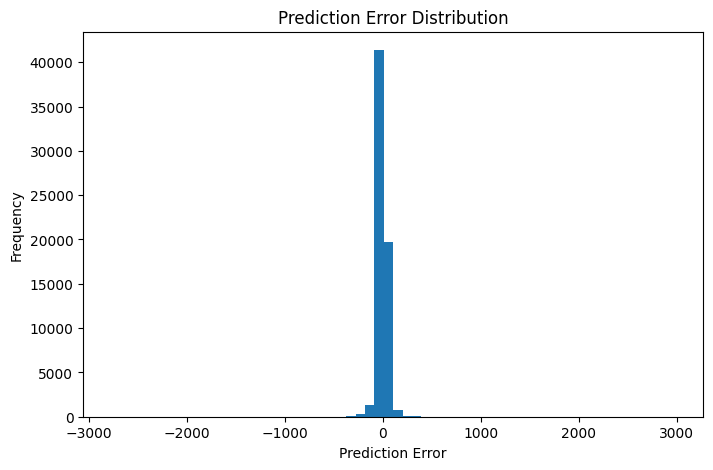

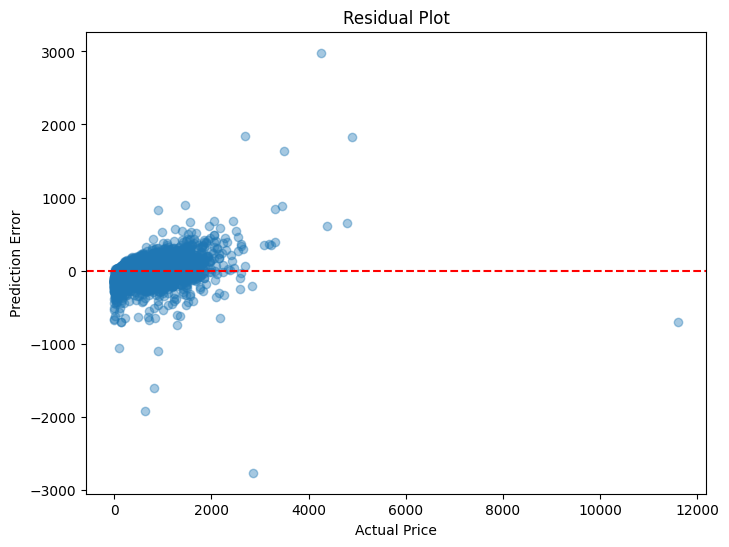

Mean Percentage Error: 156.4348189629596
Median Percentage Error: 6.112636566162109


In [14]:
# checking the performance of error analysis for the XGBoost model

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

error_df["Error"] = error_df["Actual"] - error_df["Predicted"]
error_df["Absolute Error"] = abs(error_df["Error"])
error_df["Percentage Error"] = (
    error_df["Absolute Error"] / error_df["Actual"]
) * 100

print(error_df.describe())

plt.figure(figsize=(8,5))
plt.hist(error_df["Error"], bins=60)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(error_df["Actual"], error_df["Error"], alpha=0.4)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Prediction Error")
plt.title("Residual Plot")
plt.show()

print("Mean Percentage Error:", error_df["Percentage Error"].mean())
print("Median Percentage Error:", error_df["Percentage Error"].median())

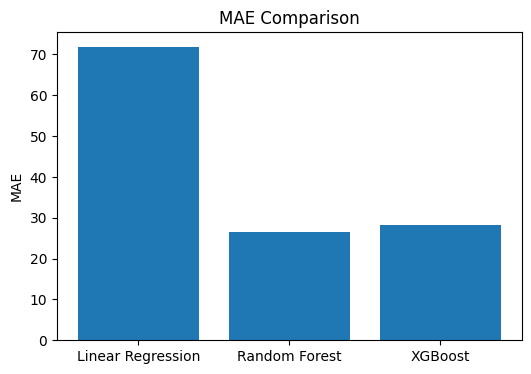

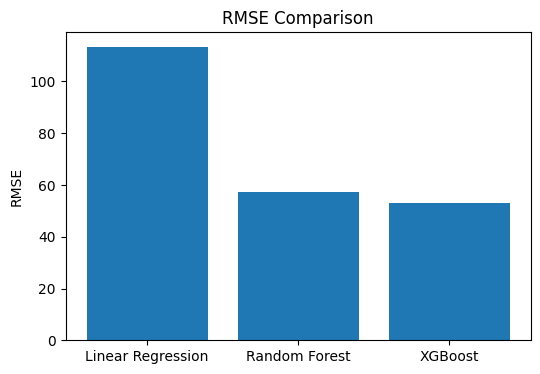

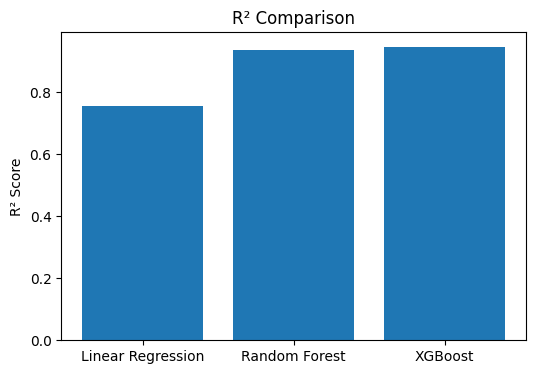

In [15]:
# Compare model performance using charts

models = ["Linear Regression", "Random Forest", "XGBoost"]

mae_scores = [lr_mae, rf_mae, xgb_mae]
rmse_scores = [lr_rmse, rf_rmse, xgb_rmse]
r2_scores = [lr_r2, rf_r2, xgb_r2]

# MAE Comparison
plt.figure(figsize=(6,4))
plt.bar(models, mae_scores)
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()

# RMSE Comparison
plt.figure(figsize=(6,4))
plt.bar(models, rmse_scores)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

# R² Comparison
plt.figure(figsize=(6,4))
plt.bar(models, r2_scores)
plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.show()

In [16]:
# Save the trained XGBoost model

joblib.dump(xgb, "xgboost_house_price.pkl")

# Save feature names

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model saved successfully.")

Model saved successfully.


In [17]:
# Download the saved model files

files.download("xgboost_house_price.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# Display the final model performance

print("=" * 60)
print("Beijing House Price Prediction")
print("=" * 60)

print(results)

print("\nBest Performing Model: XGBoost")

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

print("\nProject completed successfully!")

Beijing House Price Prediction
               Model        MAE        RMSE        R²  Training Time  \
0  Linear Regression  71.841614  113.351683  0.756898       0.353444   
1      Random Forest  26.538057   57.463897  0.937523     286.455706   
2            XGBoost  28.339468   52.979292  0.946894      10.004734   

   Prediction Time  
0         0.014378  
1         2.904898  
2         0.369209  

Best Performing Model: XGBoost
MAE  : 28.34
RMSE : 52.98
R²   : 0.9469

Project completed successfully!
